In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
bfs = pd.read_csv("/content/indian_roads_dataset.csv")

In [ ]:
bfs.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [4]:
bfs.shape

(20000, 24)

In [5]:
bfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [ ]:
bfs.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [6]:
bfs.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [7]:
bfs.isnull().sum()

,0
accident_id,0
city,0
state,0
latitude,0
longitude,0
date,0
time,0
hour,0
day_of_week,0
is_weekend,0


In [8]:
bfs.duplicated().sum()

np.int64(0)

In [9]:
bfs.dtypes

,0
accident_id,int64
city,object
state,object
latitude,float64
longitude,float64
date,object
time,object
hour,int64
day_of_week,object
is_weekend,int64


In [10]:
bfs.nunique()

,0
accident_id,20000
city,8
state,7
latitude,19907
longitude,19927
date,1201
time,24
hour,24
day_of_week,7
is_weekend,2


In [ ]:
bfs.city.unique()

array(['Pune', 'Mumbai', 'Chandigarh', 'Chennai', 'Delhi', 'Bangalore',
       'Hyderabad', 'Kolkata'], dtype=object)

Which city has the highest number of recorded accidents?

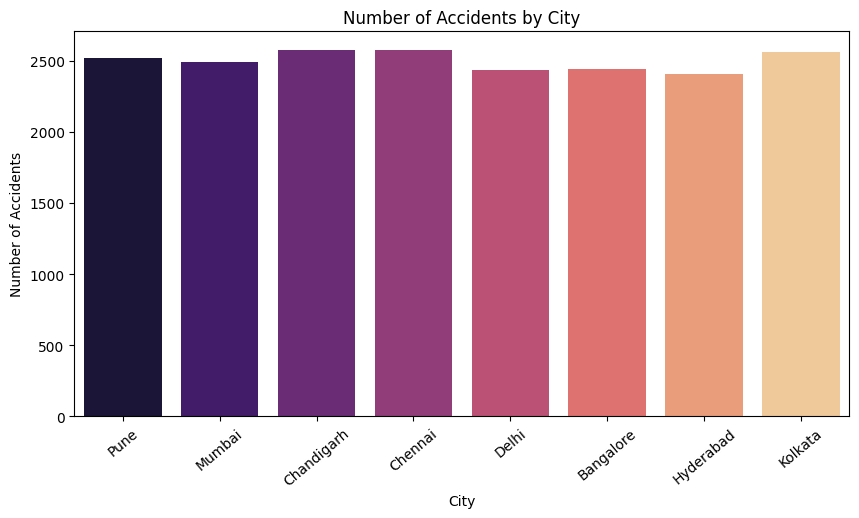

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(data=bfs, x='city', palette='magma')

plt.title('Number of Accidents by City')
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=40)
plt.show()


which severity category has the highest number of accidents.

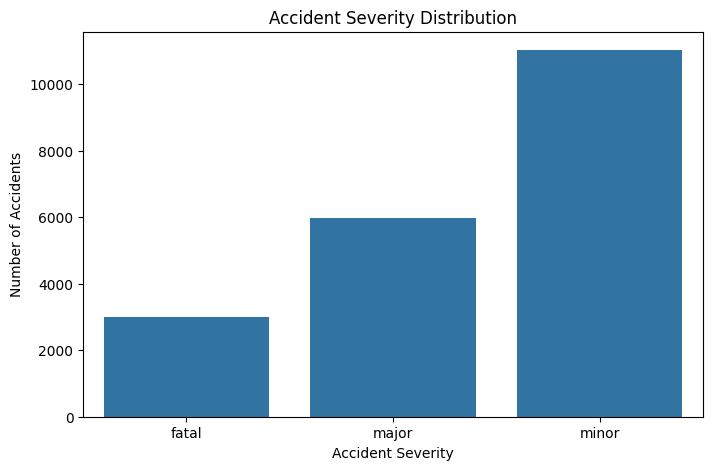

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=bfs, x='accident_severity')

plt.title('Accident Severity Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')



plt.show()

find out which causes are most common

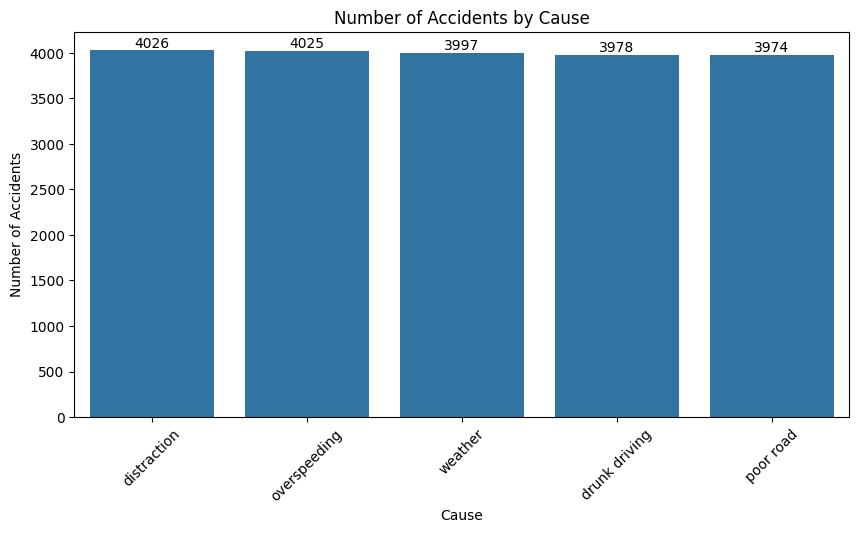

In [17]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=bfs,
    x='cause',
    order=bfs['cause'].value_counts().index
)

plt.title('Number of Accidents by Cause')
plt.xlabel('Cause')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

check whether some weather conditions have more accidents.

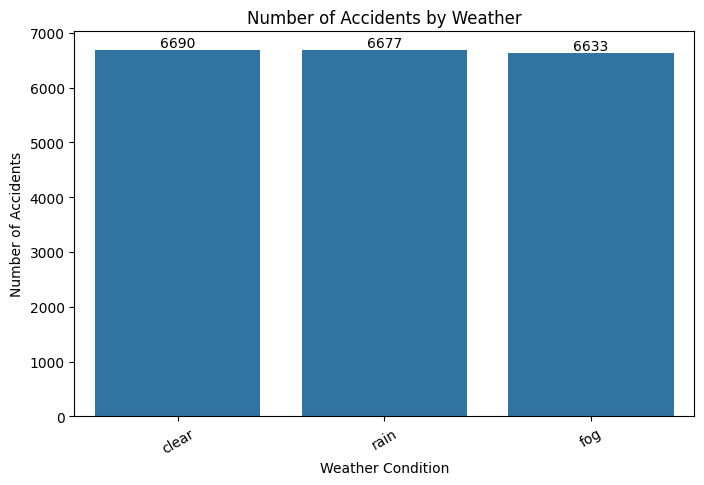

In [18]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=bfs,
    x='weather',
    order=bfs['weather'].value_counts().index
)

plt.title('Number of Accidents by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

find out which traffic density level has the most accidents.

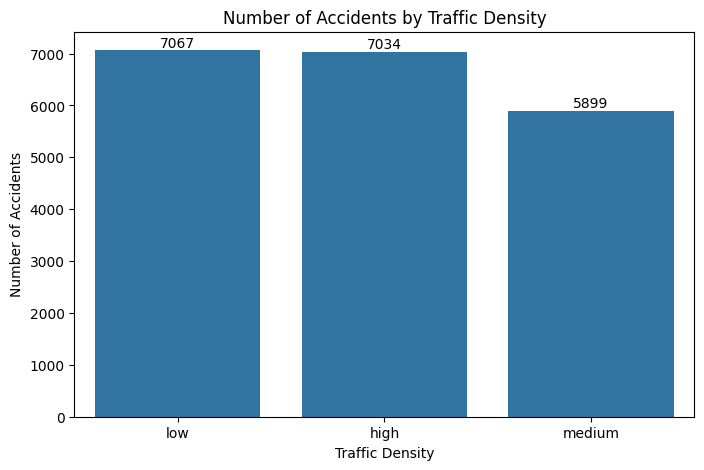

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=bfs,
    x='traffic_density',
    order=bfs['traffic_density'].value_counts().index
)

plt.title('Number of Accidents by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)
    plt.show()

which road types have the most accidents.

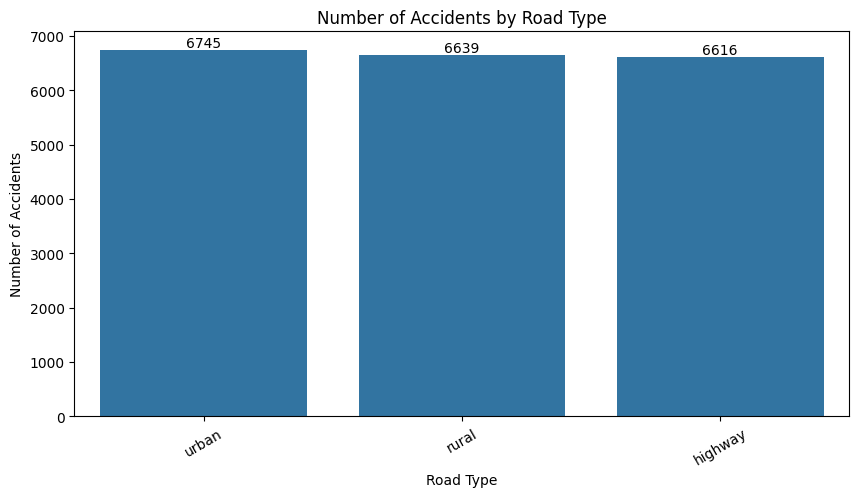

In [21]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=bfs,
    x='road_type',
    order=bfs['road_type'].value_counts().index
)

plt.title('Number of Accidents by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)
    plt.show()

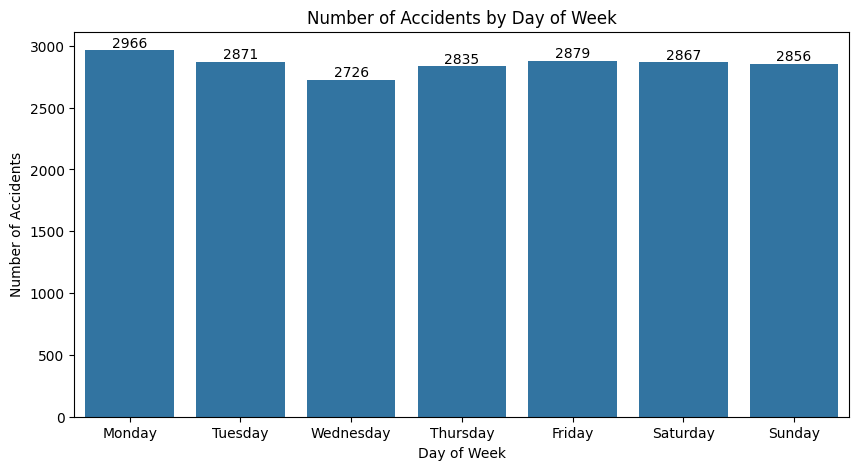

In [23]:
plt.figure(figsize=(10,5))

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
         'Friday', 'Saturday', 'Sunday']

ax = sns.countplot(
    data=bfs,
    x='day_of_week',
    order=order
)

plt.title('Number of Accidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)
    plt.show()

check whether peak hours have more accidents than non-peak hours.
o=non peak hours
1=peak hours

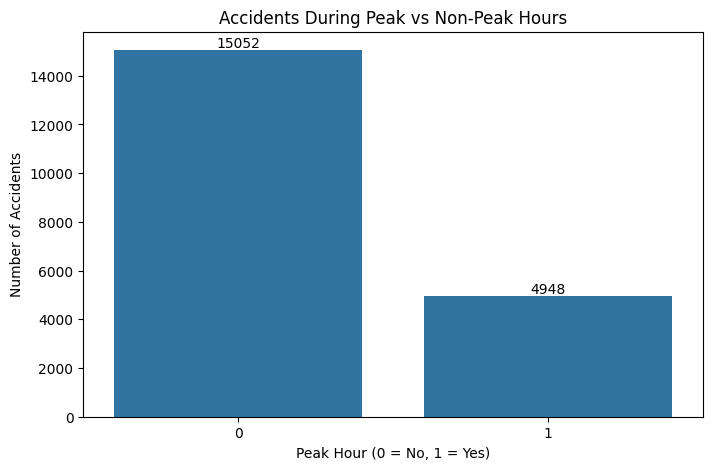

In [24]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=bfs,
    x='is_peak_hour'
)

plt.title('Accidents During Peak vs Non-Peak Hours')
plt.xlabel('Peak Hour (0 = No, 1 = Yes)')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

which causes are associated with different accident severity levels.

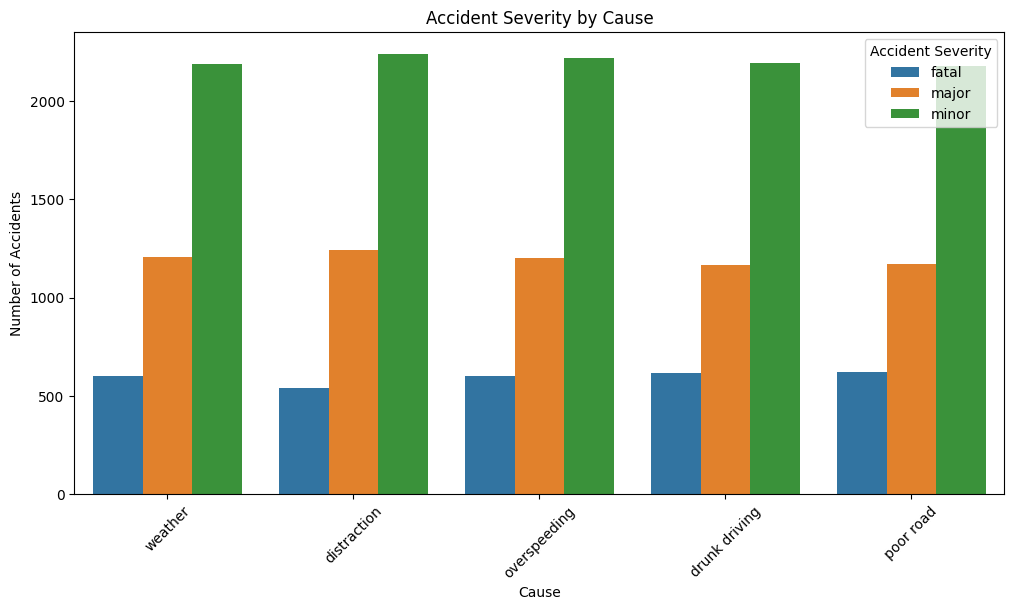

In [25]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=bfs,
    x='cause',
    hue='accident_severity'
)

plt.title('Accident Severity by Cause')
plt.xlabel('Cause')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.legend(title='Accident Severity')

plt.show()

which weather conditions are related to accident severity.

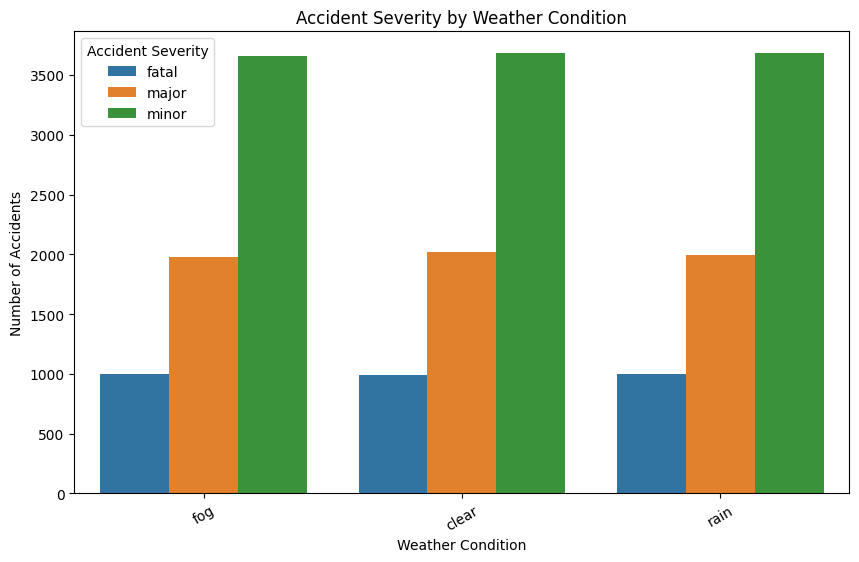

In [26]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=bfs,
    x='weather',
    hue='accident_severity'
)

plt.title('Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)

plt.legend(title='Accident Severity')

plt.show()

In [32]:
bfs['weather'].value_counts()

,count
weather,
clear,6690
rain,6677
fog,6633


Traffic Density vs Severity

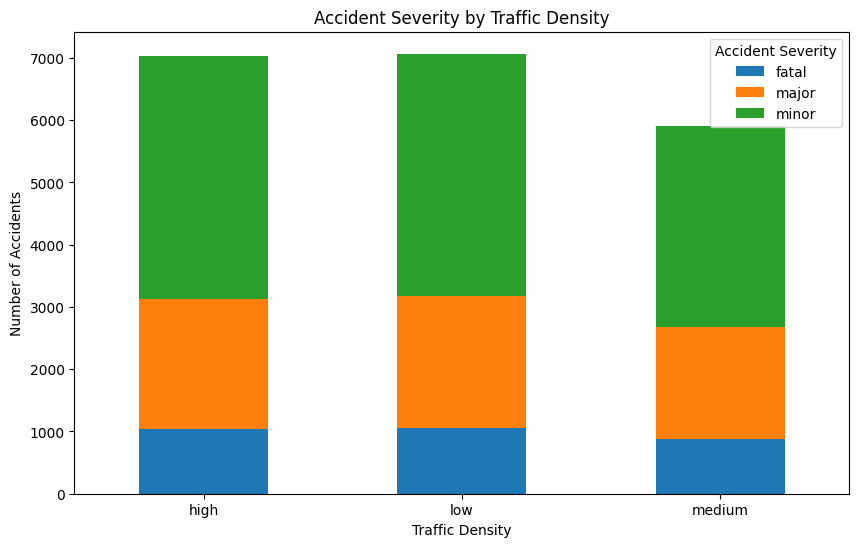

In [35]:
severity_density = pd.crosstab(
    bfs['traffic_density'],
    bfs['accident_severity']
)

severity_density.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Accident Severity by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.legend(title='Accident Severity')

plt.show()

compare accident severity across different cities.

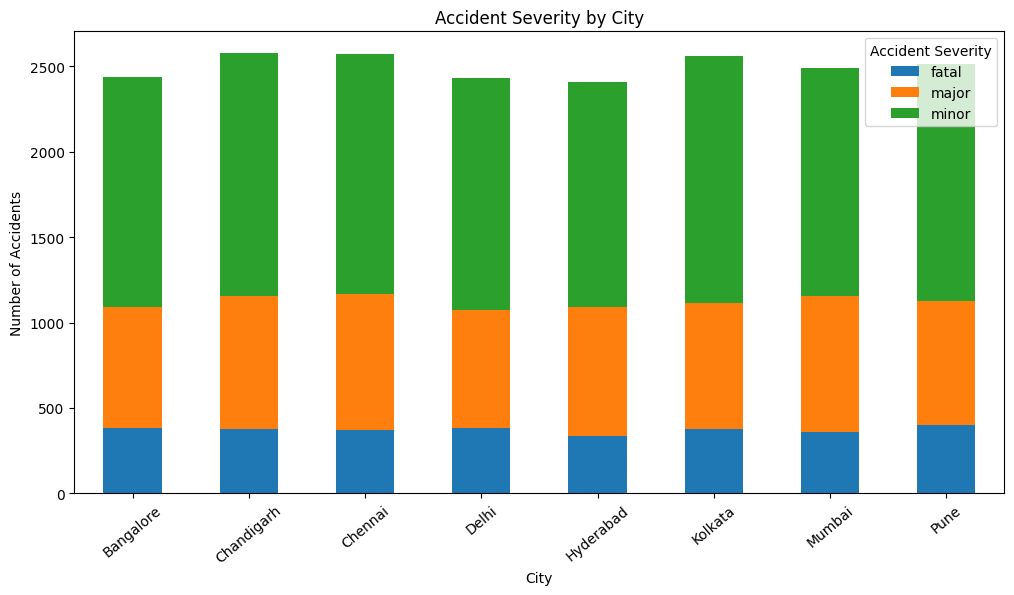

In [37]:
city_severity = pd.crosstab(
    bfs['city'],
    bfs['accident_severity']
)

city_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Accident Severity by City')
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=40)
plt.legend(title='Accident Severity')

plt.show()

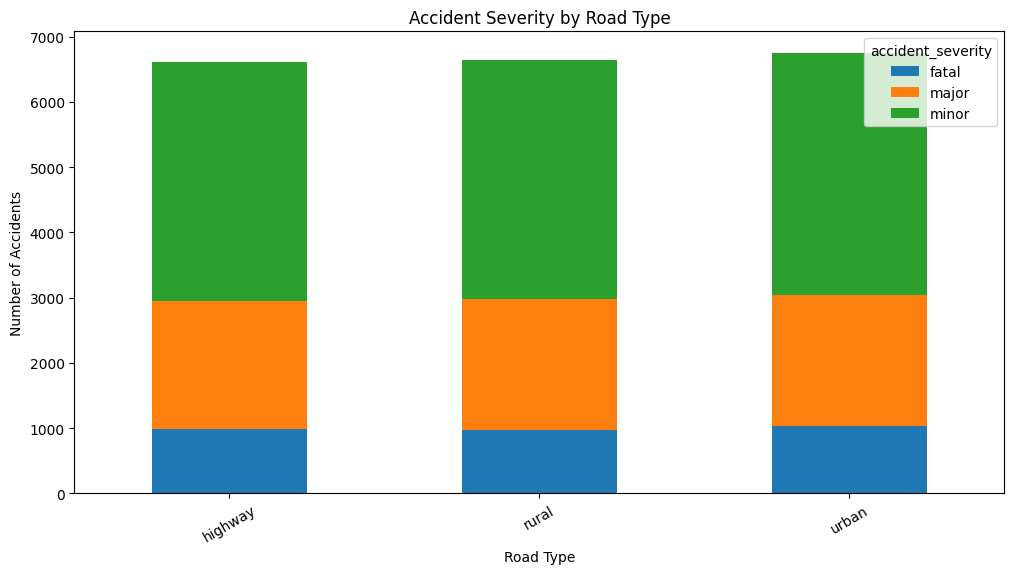

In [41]:
road_severity = pd.crosstab(
    bfs['road_type'],
    bfs['accident_severity']
)

road_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Accident Severity by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)




plt.show()

Number of Accidents by Hours

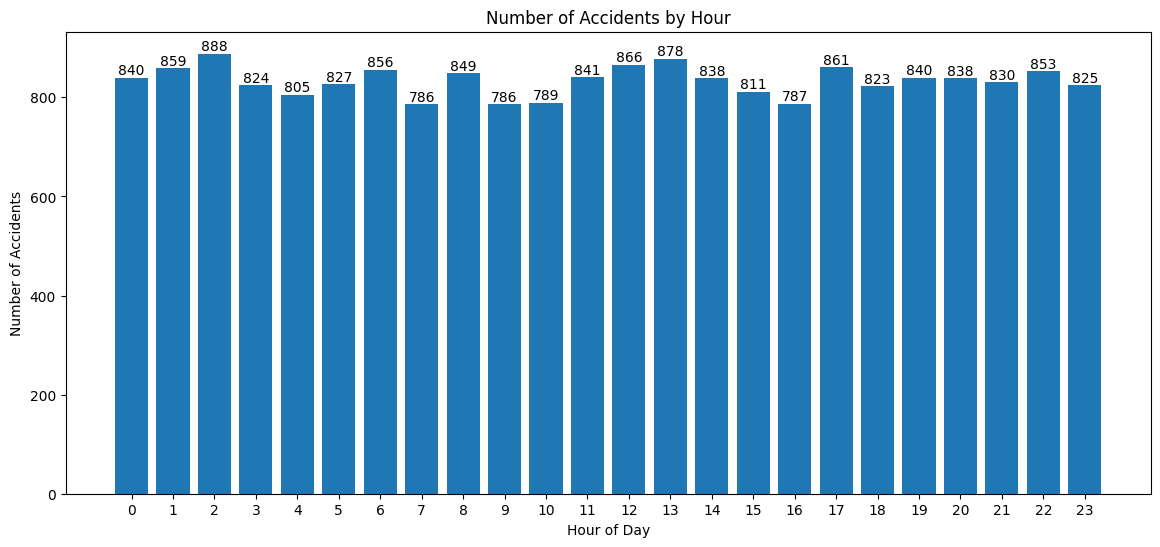

In [42]:
hourly_accidents = bfs['hour'].value_counts().sort_index()

plt.figure(figsize=(14,6))

bars = plt.bar(
    hourly_accidents.index,
    hourly_accidents.values
)

plt.title('Number of Accidents by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0,24))

plt.bar_label(bars)

plt.show()

Vehicles Involved vs Casualties

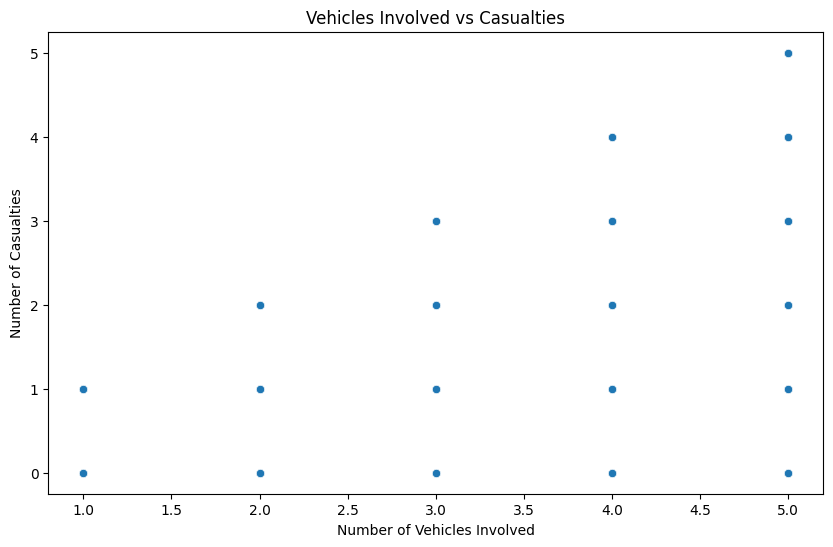

In [43]:
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=bfs,
    x='vehicles_involved',
    y='casualties'
)

plt.title('Vehicles Involved vs Casualties')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Casualties')
plt.show()

Risk Score Distribution

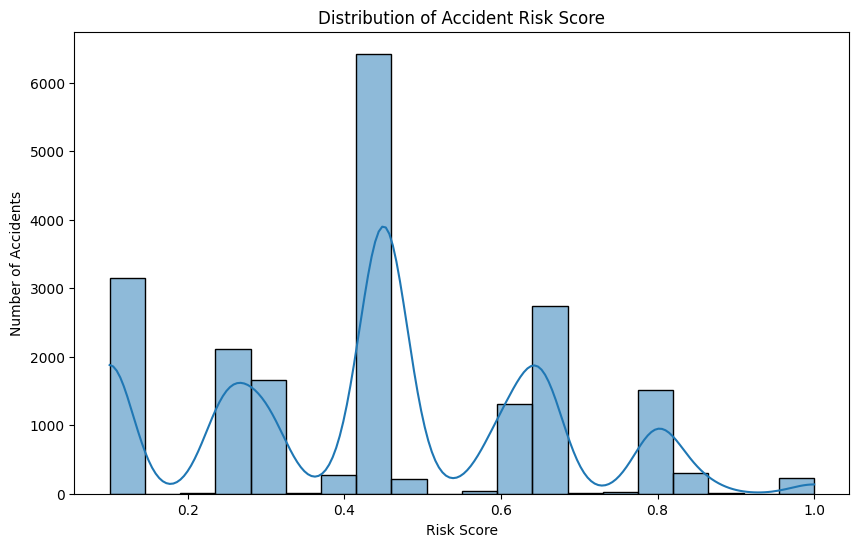

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=bfs,
    x='risk_score',
    bins=20,
    kde=True
)

plt.title('Distribution of Accident Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Number of Accidents')

plt.show()

Correlation Analysis

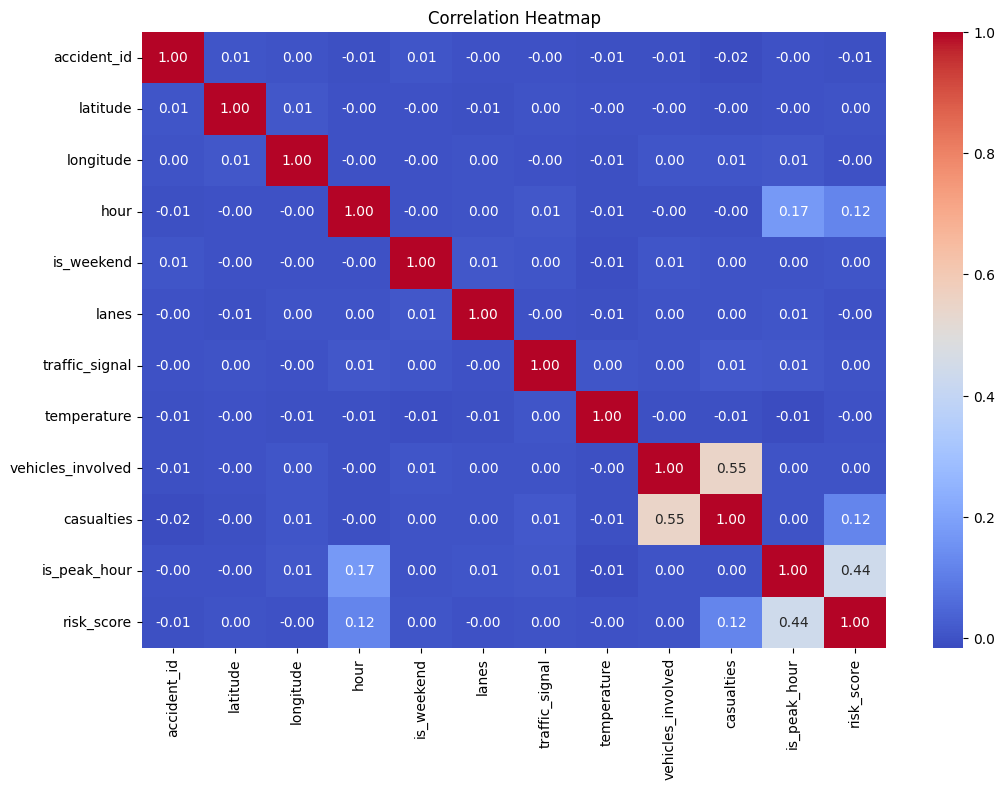

In [45]:
plt.figure(figsize=(12,8))

numeric_data = bfs.select_dtypes(include='number')

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

Do severe accidents have higher risk scores than minor accidents?

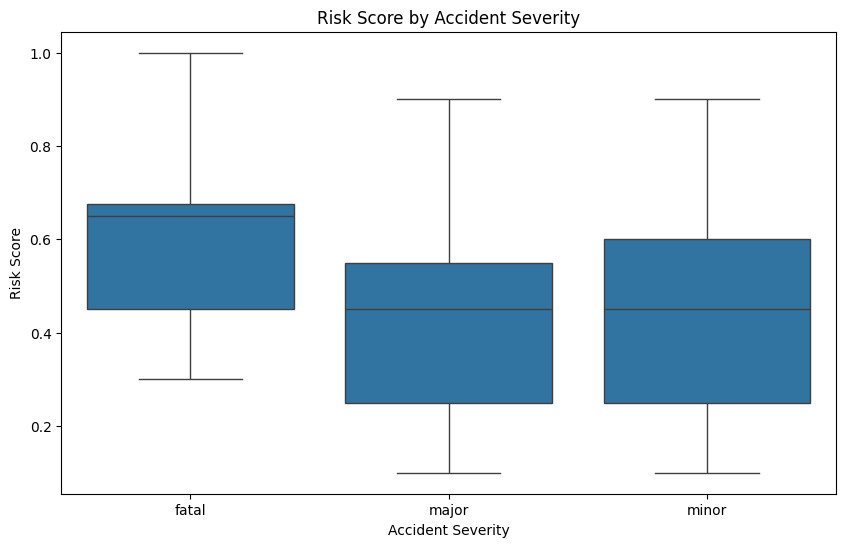

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=bfs,
    x='accident_severity',
    y='risk_score'
)

plt.title('Risk Score by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Risk Score')

plt.show()

Month wise accident analysis

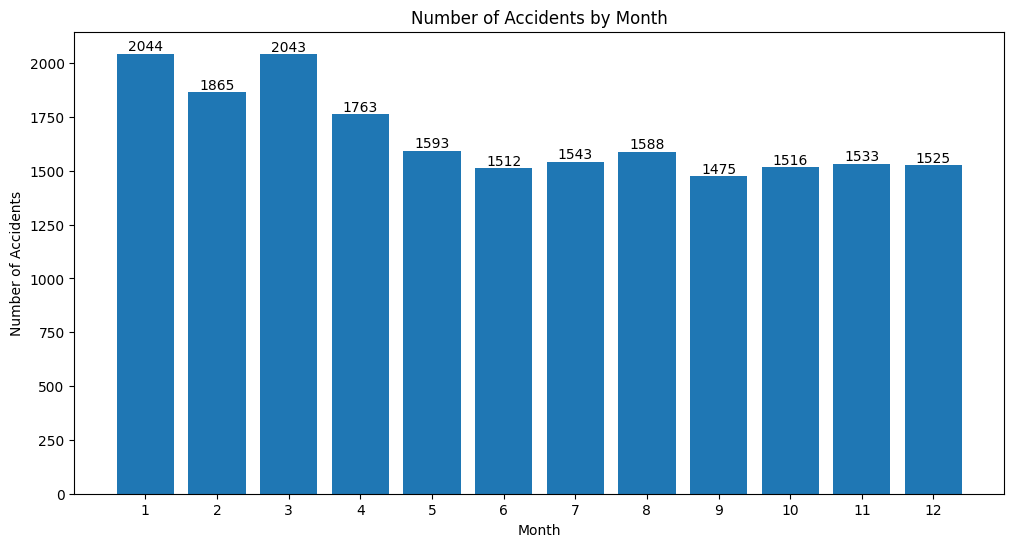

In [47]:
bfs['date'] = pd.to_datetime(bfs['date'])

bfs['month'] = bfs['date'].dt.month

monthly_accidents = bfs['month'].value_counts().sort_index()

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_accidents.index,
    monthly_accidents.values
)

plt.title('Number of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(range(1, 13))

plt.bar_label(bars)

plt.show()

Weekend vs Weekday

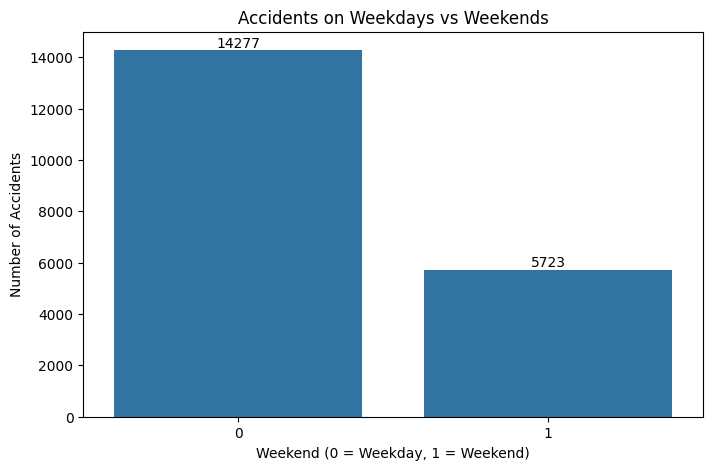

In [48]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=bfs,
    x='is_weekend'
)

plt.title('Accidents on Weekdays vs Weekends')
plt.xlabel('Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Accidents by State

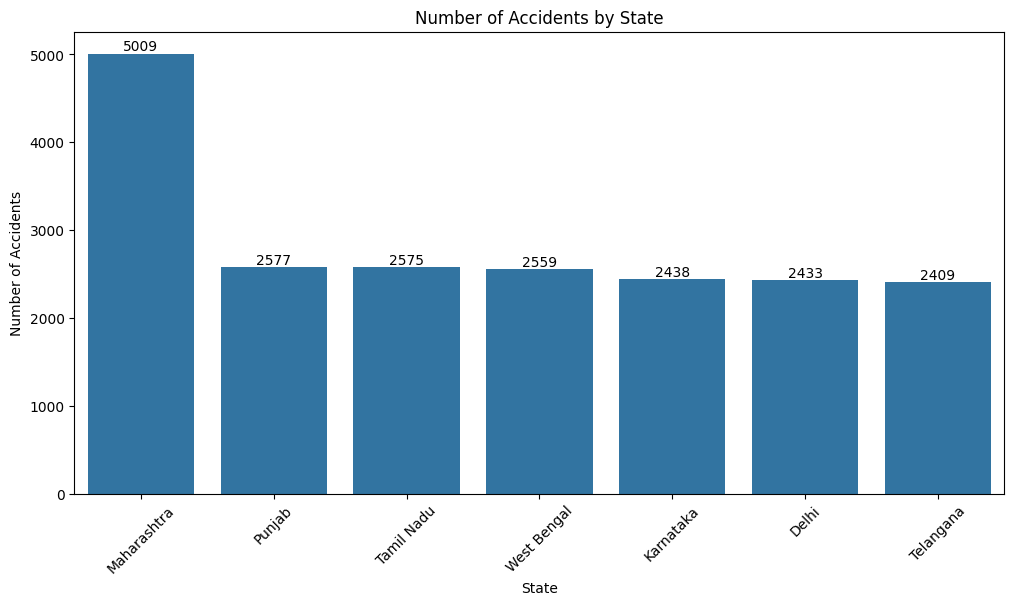

In [49]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=bfs,
    x='state',
    order=bfs['state'].value_counts().index
)

plt.title('Number of Accidents by State')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Accident Severity Percentage

In [50]:
severity_percentage = (
    bfs['accident_severity']
    .value_counts(normalize=True)
    * 100
)

print(severity_percentage)

accident_severity
minor    55.125
major    29.940
fatal    14.935
Name: proportion, dtype: float64


Cause Percentage

In [51]:
cause_percentage = (
    bfs['cause']
    .value_counts(normalize=True)
    * 100
)

print(cause_percentage)

cause
distraction      20.130
overspeeding     20.125
weather          19.985
drunk driving    19.890
poor road        19.870
Name: proportion, dtype: float64


In [52]:
avg_casualties = bfs.groupby('accident_severity')['casualties'].mean()

print(avg_casualties)

accident_severity
fatal    3.001674
major    1.494823
minor    1.506757
Name: casualties, dtype: float64


city
Bangalore     0.440217
Chandigarh    0.441618
Chennai       0.437573
Delhi         0.437115
Hyderabad     0.439456
Kolkata       0.434584
Mumbai        0.434350
Pune          0.435836
Name: risk_score, dtype: float64


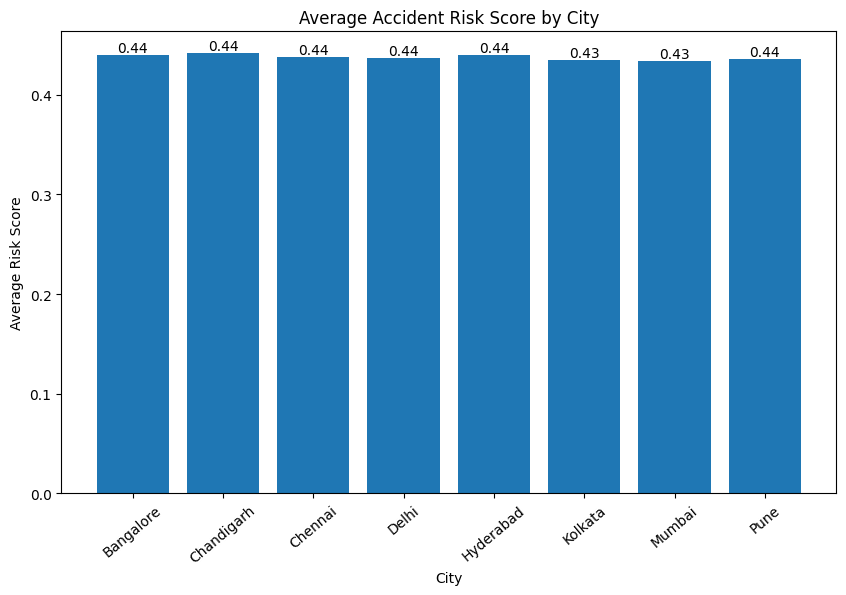

In [55]:
plt.figure(figsize=(10,6))
city_risk = bfs.groupby('city')['risk_score'].mean()
print(city_risk)

bars = plt.bar(city_risk.index, city_risk.values)

plt.title('Average Accident Risk Score by City')
plt.xlabel('City')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=40)

plt.bar_label(bars, fmt='%.2f')

plt.show()

In [57]:
cause_risk = bfs.groupby('cause')['risk_score'].mean().sort_values(ascending=False)

print(cause_risk)

cause
overspeeding     0.440186
poor road        0.439796
weather          0.439742
drunk driving    0.438964
distraction      0.429297
Name: risk_score, dtype: float64


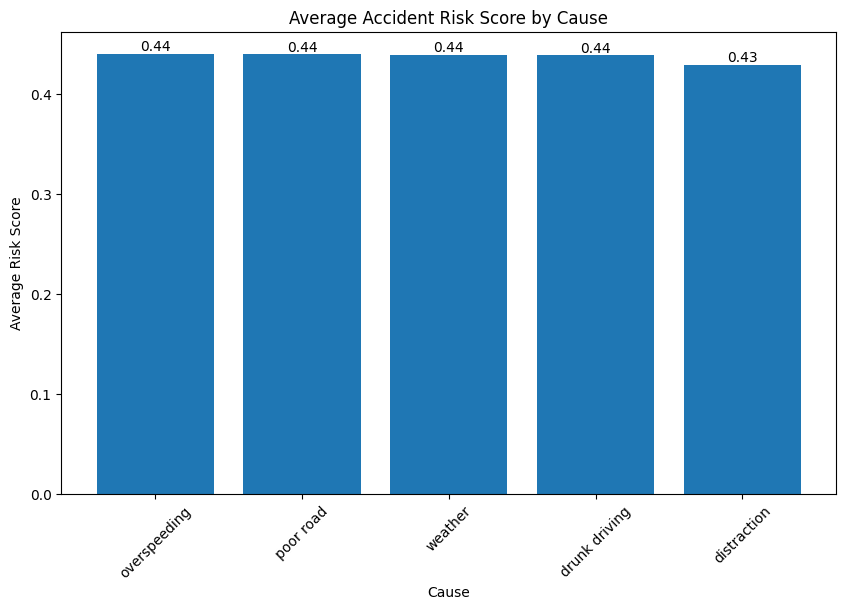

In [58]:
plt.figure(figsize=(10,6))

bars = plt.bar(cause_risk.index, cause_risk.values)

plt.title('Average Accident Risk Score by Cause')
plt.xlabel('Cause')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=45)

plt.bar_label(bars, fmt='%.2f')

plt.show()